# 04b — Series Outcome Modeling

Train and compare models predicting **who wins each playoff series**.

**Input:** `data/processed/series_features.parquet`  
**Train:** 2014-15 through 2021-22 | **Test:** 2022-23 and 2023-24

**Baseline:** higher seed wins ~65% of series — any model must beat this.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

sns.set_theme(style="whitegrid")
sys.path.insert(0, str(Path().resolve().parent))
from src.models import (
    build_logistic_pipeline, build_random_forest_pipeline, build_xgboost_pipeline,
    compare_models, evaluate_model, save_model, train_test_split_by_season,
)

In [2]:
# CONFIG
PROCESSED_DIR = Path().resolve().parent / "data" / "processed"
FEATURES_PATH = PROCESSED_DIR / "series_features.parquet"
TEST_SEASONS = ["2022-23", "2023-24"]
TARGET_COL = "higher_seed_wins"

FEATURE_COLS = [
    "home_ortg", "away_ortg", "home_drtg", "away_drtg",
    "home_net_rtg", "away_net_rtg", "net_rtg_diff",
    "home_pace", "away_pace", "ortg_diff", "drtg_diff",
    "home_win_pct", "away_win_pct", "win_pct_diff",
    "home_oreb_pct", "away_oreb_pct",
    "home_tov_pct", "away_tov_pct",
    "home_playoff_win_pct_3yr", "away_playoff_win_pct_3yr", "playoff_win_pct_diff",
    "home_finals_apps_5yr", "away_finals_apps_5yr",
]

## 1. Load + Split

In [3]:
df = pd.read_parquet(FEATURES_PATH)
train_df, test_df = train_test_split_by_season(df, TEST_SEASONS)

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET_COL]

print(f"Train: {len(train_df)} series | Test: {len(test_df)} series")
print(f"Train higher-seed win rate: {y_train.mean():.1%}")
print(f"Test  higher-seed win rate: {y_test.mean():.1%}")
print(f"\nNaive baseline (always pick higher seed): {y_test.mean():.1%}")

Train: 105 series | Test: 30 series
Train higher-seed win rate: 79.0%
Test  higher-seed win rate: 56.7%

Naive baseline (always pick higher seed): 56.7%


## 2. Train All Models

In [4]:
models = {
    "logistic_regression": build_logistic_pipeline(),
    "random_forest":        build_random_forest_pipeline(),
    "xgboost":              build_xgboost_pipeline(),
}
for name, m in models.items():
    m.fit(X_train, y_train)
    print(f"Trained {name}")

Trained logistic_regression
Trained random_forest


Trained xgboost


## 3. Cross-Validation (Temporal)

In [5]:
tscv = TimeSeriesSplit(n_splits=5)
print("CV AUC (TimeSeriesSplit on training data):")
for name, m in models.items():
    scores = cross_val_score(m, X_train, y_train, cv=tscv, scoring="roc_auc")
    print(f"  {name}: {scores.mean():.3f} ± {scores.std():.3f}")

CV AUC (TimeSeriesSplit on training data):
  logistic_regression: 0.687 ± 0.176


  random_forest: 0.674 ± 0.163


  xgboost: 0.642 ± 0.127


## 4. Holdout Evaluation

In [6]:
holdout = {name: evaluate_model(m, X_test, y_test) for name, m in models.items()}
results_df = compare_models(holdout)
print("Holdout results (2022-24 seasons):")
print(results_df.to_string())

Holdout results (2022-24 seasons):
                     accuracy  roc_auc  log_loss  brier_score
model                                                        
xgboost                0.5333   0.6833    1.2868       0.3798
random_forest          0.5667   0.6742    0.7783       0.2715
logistic_regression    0.5333   0.6471    0.9448       0.3096


## 5. ROC + Calibration Curves

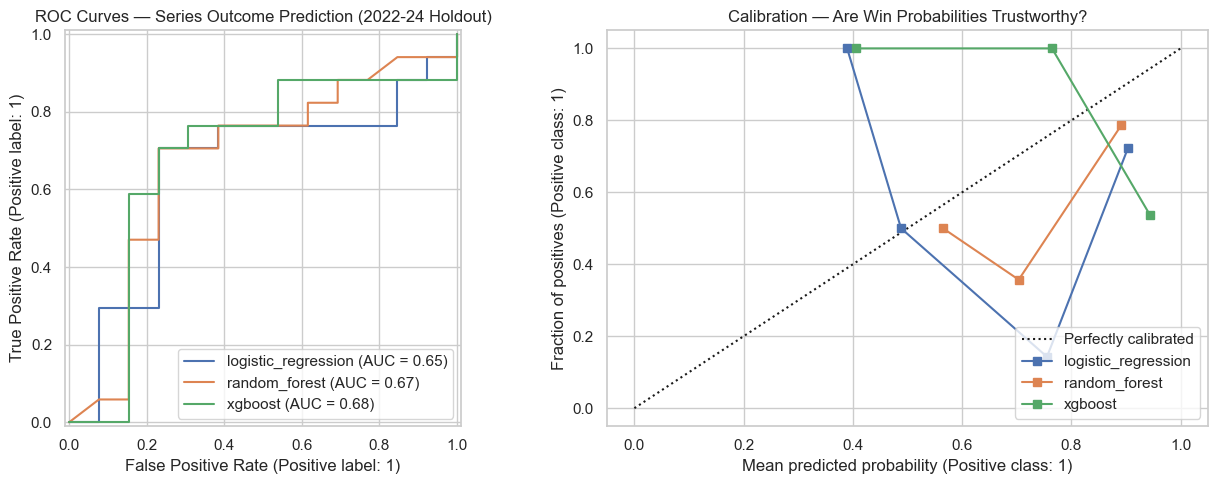

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, m in models.items():
    RocCurveDisplay.from_estimator(m, X_test, y_test, ax=axes[0], name=name)
axes[0].set_title("ROC Curves — Series Outcome Prediction (2022-24 Holdout)")

for name, m in models.items():
    CalibrationDisplay.from_estimator(m, X_test, y_test, n_bins=5, ax=axes[1], name=name)
axes[1].set_title("Calibration — Are Win Probabilities Trustworthy?")

plt.tight_layout()
plt.show()

## 6. Accuracy by Round

Accuracy by round (xgboost):
 round_name  mean  count
First Round 0.625     16
 Conf Semis 0.250      8
Conf Finals 0.500      4
     Finals 1.000      2


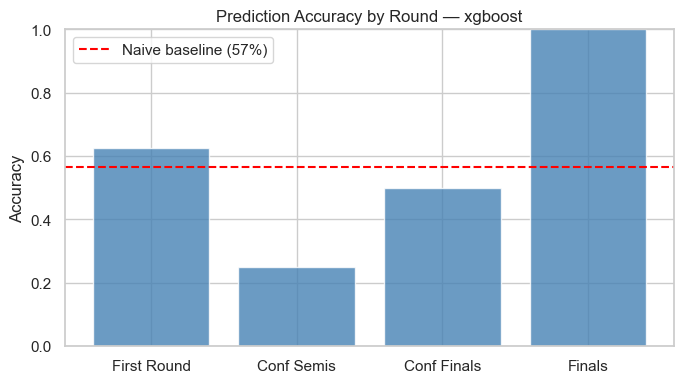

In [8]:
# Best model by AUC
best_name = results_df.index[0]
best_model = models[best_name]

test_df = test_df.copy()
test_df["predicted"] = best_model.predict(X_test)
test_df["correct"] = (test_df["predicted"] == test_df[TARGET_COL]).astype(int)

round_map = {1: "First Round", 2: "Conf Semis", 3: "Conf Finals", 4: "Finals"}
by_round = test_df.groupby("round")["correct"].agg(["mean", "count"]).reset_index()
by_round["round_name"] = by_round["round"].map(round_map)
print(f"Accuracy by round ({best_name}):")
print(by_round[["round_name", "mean", "count"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(by_round["round_name"], by_round["mean"], color="steelblue", alpha=0.8)
ax.axhline(y_test.mean(), color="red", linestyle="--", label=f"Naive baseline ({y_test.mean():.0%})")
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title(f"Prediction Accuracy by Round — {best_name}")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Save Best Model

In [9]:
path = save_model(best_model, f"series_{best_name}")
print(f"Best model: {best_name}")
print(f"Saved to: {path}")

Best model: xgboost
Saved to: /Users/mearly/dev/playground/Sports/nba-playoffs/models/series_xgboost.joblib
